# SmartNoise Synthetic Data EDA

Explore differentially private synthetic data generation with OpenDP SmartNoise on the Kaggle credit card fraud dataset.

**Metric dimensions:** statistical fidelity, temporal, privacy, Azure compatibility, utility.

## 1. Setup

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import (
    aggregate_bootstrap_metrics,
    create_seed_and_holdout,
    DEFAULT_TARGET_COLUMN,
    stratified_bootstrap,
)
from src.kaggle_data import load_creditcard
from src.metrics import compute_all_metrics
from src.synthesis import fit_sample_smartnoise, privacy_budget_dict

TARGET_COLUMN = DEFAULT_TARGET_COLUMN

SEED = 42
SAMPLE_SIZE = 2000
HOLDOUT_SIZE = 5000
POOL_SIZE = 10000
EPSILON = 1.0
PREPROCESSOR_EPS = 0.0
BOOTSTRAP_N = 30
SYNTHESIZER = "mwem"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

sns.set_theme(style="whitegrid")
np.random.seed(SEED)

## 2. Download & Load

In [3]:
import kagglehub

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

csv_path = Path(path) / "creditcard.csv"
if not csv_path.exists():
    csv_path = next(Path(path).rglob("creditcard.csv"))

df_full = load_creditcard(csv_path)
print(f"Full dataset: {len(df_full):,} rows, {df_full.shape[1]} columns")
print(f"Fraud rate: {df_full[TARGET_COLUMN].mean():.4%}")

Path to dataset files: /Users/amin/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3
Full dataset: 284,807 rows, 31 columns
Fraud rate: 0.1727%


In [7]:
df_full.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Time,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.0,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0.0,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.0,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1.0,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,2.0,69.99,0


In [4]:
seed_df, holdout_df, pool_df = create_seed_and_holdout(
    df_full,
    seed_size=SAMPLE_SIZE,
    holdout_size=HOLDOUT_SIZE,
    pool_size=POOL_SIZE,
    random_state=SEED,
)

print(f"Seed sample: {len(seed_df):,} rows, fraud rate {seed_df[TARGET_COLUMN].mean():.4%}")
print(f"Holdout:     {len(holdout_df):,} rows, fraud rate {holdout_df[TARGET_COLUMN].mean():.4%}")
print(f"Bootstrap pool: {len(pool_df):,} rows")

Seed sample: 2,000 rows, fraud rate 0.1500%
Holdout:     5,000 rows, fraud rate 0.1800%
Bootstrap pool: 10,000 rows


## 3. Seed EDA

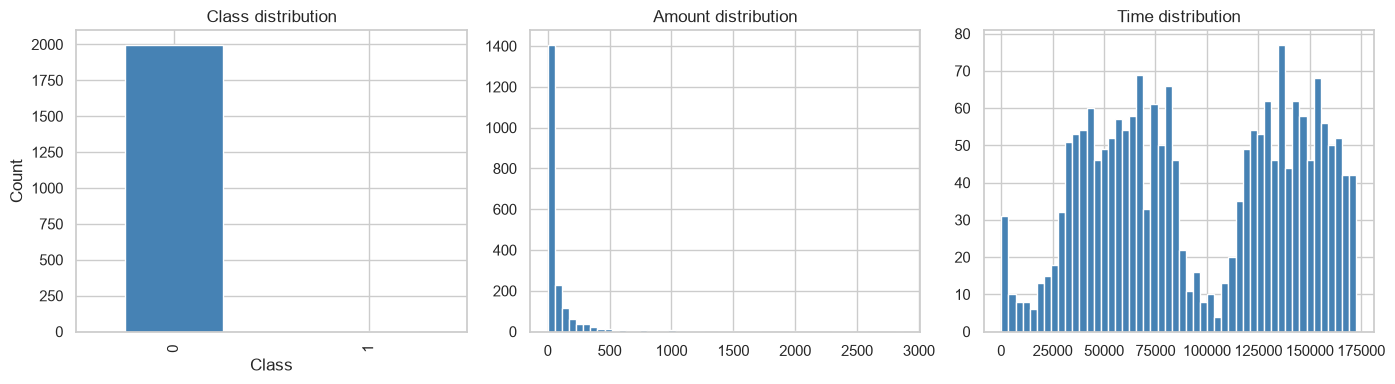

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

seed_df[TARGET_COLUMN].value_counts().plot.bar(ax=axes[0], color=["steelblue", "coral"])
axes[0].set_title("Class distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

seed_df["Amount"].hist(bins=50, ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title("Amount distribution")

seed_df["Time"].hist(bins=50, ax=axes[2], color="steelblue", edgecolor="white")
axes[2].set_title("Time distribution")

plt.tight_layout()
plt.show()

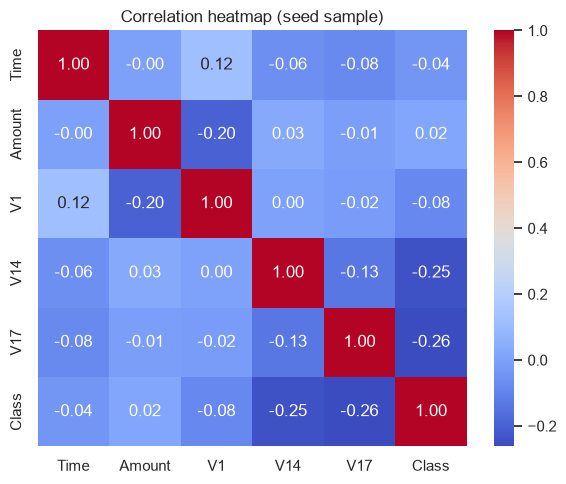

In [6]:
fraud_cols = ["V1", "V14", "V17"]
corr_cols = ["Time", "Amount"] + fraud_cols + [TARGET_COLUMN]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(seed_df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation heatmap (seed sample)")
plt.tight_layout()
plt.show()

## 4. Synthesize with SmartNoise

In [8]:
result = fit_sample_smartnoise(
    seed_df,
    synthesizer_name=SYNTHESIZER,
    epsilon=EPSILON,
    preprocessor_eps=PREPROCESSOR_EPS,
    verbose=True,
)

synthetic_df = result.synthetic
privacy_budget = privacy_budget_dict(result)

print(f"Synthesizer: {result.synthesizer_name}")
print(f"Privacy budget spent: epsilon={result.spent_epsilon:.4f}, delta={result.spent_delta}")
print(f"Synthetic rows: {len(synthetic_df):,}")
print(f"Synthetic fraud rate: {synthetic_df[TARGET_COLUMN].mean():.4%}")
print(
    "Note: MWEM with low epsilon may suppress rare fraud rows (expected DP trade-off). "
    "Utility TSTR metrics require both classes in synthetic data."
)
synthetic_df.head()

Processing 31 histograms

Histogram #0 split: [0]
Columns: 1
Dimensionality: 10
Cuboids possible: 1
1-2-way cuboids possible: 1
Fitting for 10 iterations
Number of queries: 20
Number of slices in queries: 200
Per-Measure Epsilon: 0.002
Measurement Error: 1427.60

Histogram #1 split: [1]
Columns: 1
Dimensionality: 10
Cuboids possible: 1
1-2-way cuboids possible: 1
Fitting for 10 iterations
Number of queries: 20
Number of slices in queries: 200
Per-Measure Epsilon: 0.002
Measurement Error: 1427.60

Histogram #2 split: [2]
Columns: 1
Dimensionality: 10
Cuboids possible: 1
1-2-way cuboids possible: 1
Fitting for 10 iterations
Number of queries: 20
Number of slices in queries: 200
Per-Measure Epsilon: 0.002
Measurement Error: 1427.60

Histogram #3 split: [3]
Columns: 1
Dimensionality: 10
Cuboids possible: 1
1-2-way cuboids possible: 1
Fitting for 10 iterations
Number of queries: 20
Number of slices in queries: 200
Per-Measure Epsilon: 0.002
Measurement Error: 1427.60

Histogram #4 split: [4

/Users/amin/Desktop/synthetic_data_generation/.venv/lib/python3.14/site-packages/snsynth/mwem.py:492: Warning: Flattened dimensionality of synthetic histogram is less than the number of iterations. This is a privacy risk. Consider increasing your split_factor (especially if it is 1), or decreasing the number of iterations. Dim: 2 Split: [30]
  warnings.warn(


Synthesizer: mwem
Privacy budget spent: epsilon=1.0000, delta=0.0
Synthetic rows: 2,000
Synthetic fraud rate: 3.0000%
Note: MWEM with low epsilon may suppress rare fraud rows (expected DP trade-off). Utility TSTR metrics require both classes in synthetic data.


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Time,Amount,Class
0,-1.509334,-2.137144,0.528240,0.579056,1.322818,-0.501423,4.166993,-1.610165,-2.107024,0.376358,...,1.856072,0.410771,-0.573120,0.583520,1.468879,-0.254197,-3.146880,133795.475,14.34445,0
1,2.241099,-2.137144,1.986615,-0.592226,1.322818,-2.147627,-1.084818,-1.610165,-2.107024,0.376358,...,1.856072,0.410771,-0.573120,-0.497034,0.564867,-0.254197,-0.127120,171756.255,1592.23395,0
2,0.365883,0.755377,1.986615,0.579056,-11.731482,-3.793831,-1.084818,0.651770,0.413617,0.376358,...,0.585937,0.410771,-1.021743,-0.497034,-0.339145,-0.254197,0.879467,152775.865,1592.23395,0
3,0.365883,-2.137144,-3.846887,0.579056,17.640693,-0.501423,4.166993,0.651770,-0.846703,0.376358,...,0.585937,0.410771,-1.021743,-0.497034,0.564867,-0.254197,-0.127120,171756.255,14.34445,0
4,-1.509334,-2.137144,-8.222013,-0.592226,1.322818,-0.501423,4.166993,0.651770,5.454898,2.579848,...,1.856072,-1.277110,-0.573120,0.583520,0.112861,-0.254197,-0.127120,133795.475,14.34445,0


## 5. Metric Dashboard (single run)

In [9]:
metrics = compute_all_metrics(
    real_train=seed_df,
    synthetic=synthetic_df,
    real_holdout=holdout_df,
    privacy_budget=privacy_budget,
    output_dir=str(OUTPUT_DIR),
    synthesizer_name=SYNTHESIZER,
)

metrics_df = pd.DataFrame([metrics]).T
metrics_df.columns = ["value"]
metrics_df.index.name = "metric"
metrics_df

/Users/amin/Desktop/synthetic_data_generation/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/amin/Desktop/synthetic_data_generation/.venv/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/amin/Desktop/synthetic_data_generation/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarnin

,value
metric,
fidelity_ks_mean,0.486267
fidelity_ks_max,0.861000
fidelity_wasserstein_mean,1240.514447
fidelity_mean_pct_error,60.850048
fidelity_std_pct_error,1.339390
fidelity_corr_l2_diff,2.212007
fidelity_class_prevalence_error,0.028500
temporal_time_ks,0.425000
temporal_gap_ks,0.990995


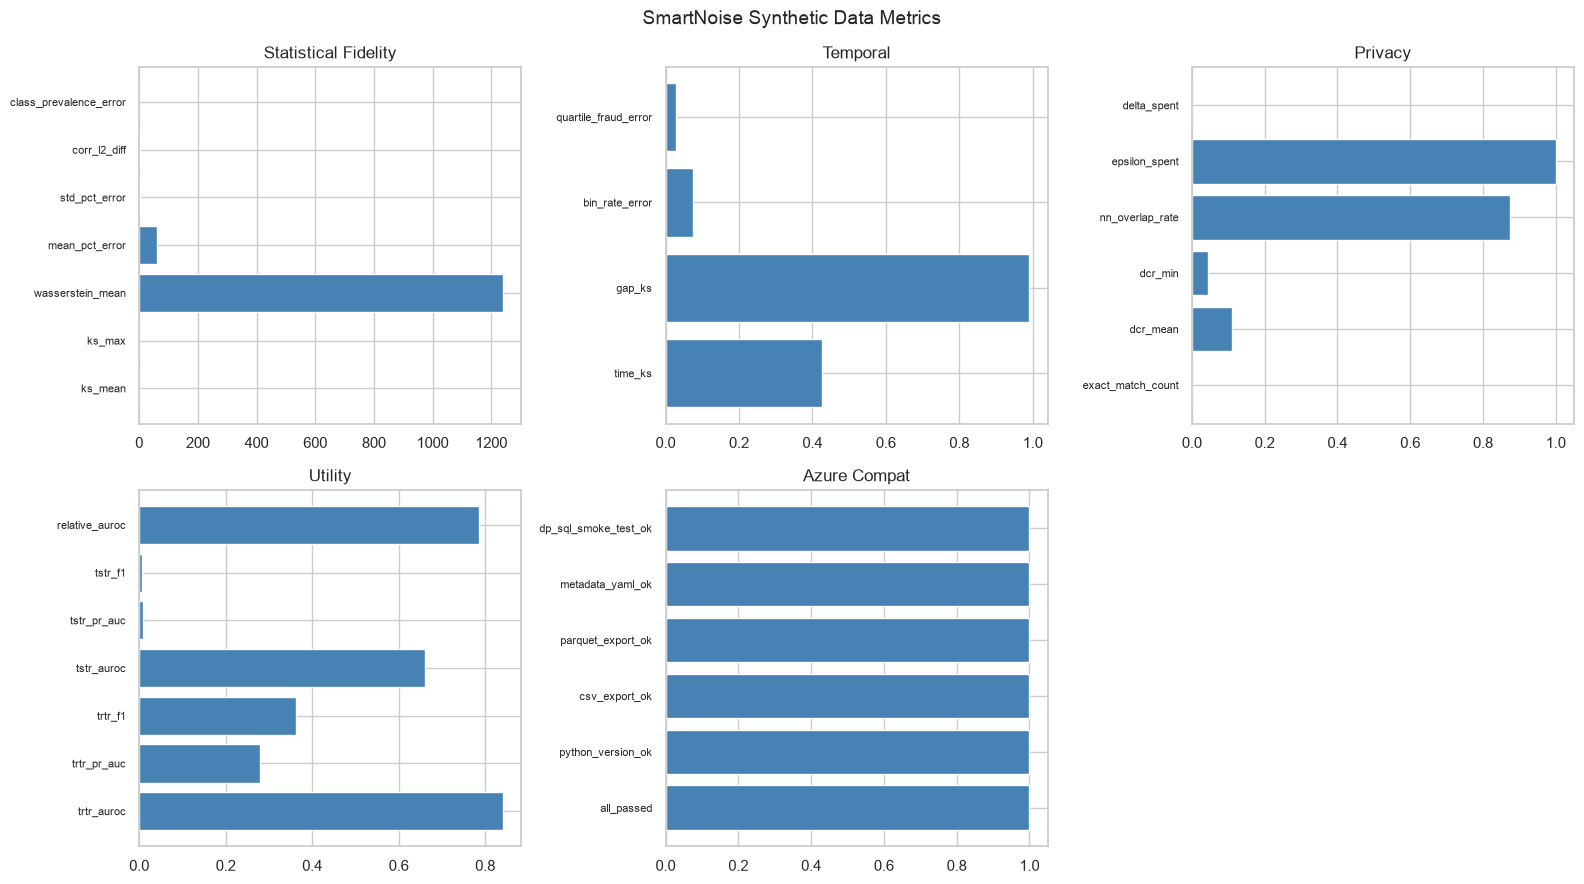

In [10]:
def plot_metric_groups(metrics: dict):
    groups = {
        "Statistical Fidelity": [k for k in metrics if k.startswith("fidelity_")],
        "Temporal": [k for k in metrics if k.startswith("temporal_")],
        "Privacy": [k for k in metrics if k.startswith("privacy_")],
        "Utility": [k for k in metrics if k.startswith("utility_")],
        "Azure Compat": [k for k in metrics if k.startswith("azure_")],
    }

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()

    for ax, (title, keys) in zip(axes, groups.items()):
        vals = [metrics[k] for k in keys if not np.isnan(metrics.get(k, np.nan))]
        labels = [k.split("_", 1)[1] for k in keys if not np.isnan(metrics.get(k, np.nan))]
        if vals:
            ax.barh(labels, vals, color="steelblue")
        ax.set_title(title)
        ax.tick_params(axis="y", labelsize=8)

    axes[-1].axis("off")
    plt.suptitle("SmartNoise Synthetic Data Metrics", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_metric_groups(metrics)

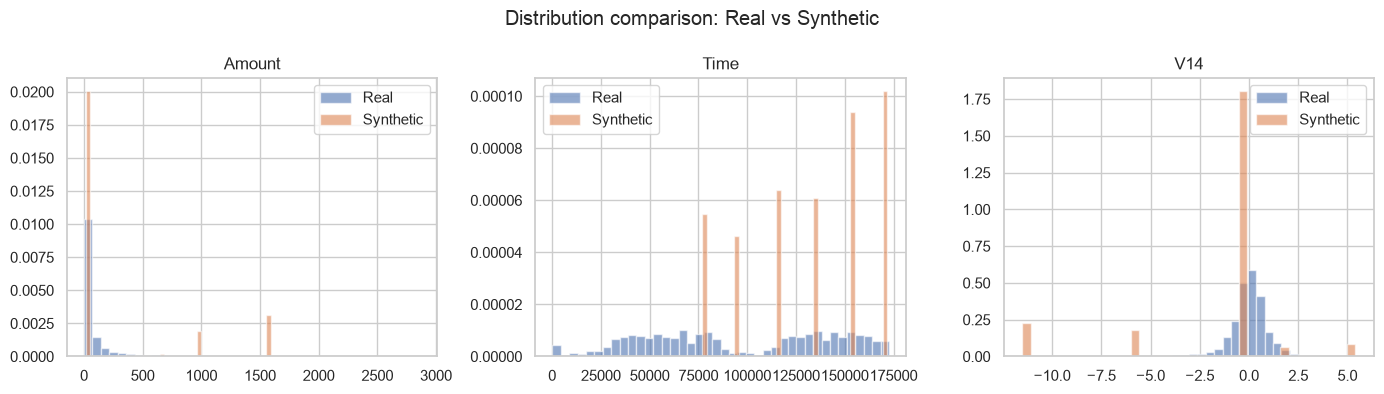

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["Amount", "Time", "V14"]):
    ax.hist(seed_df[col], bins=40, alpha=0.6, label="Real", density=True)
    ax.hist(synthetic_df[col], bins=40, alpha=0.6, label="Synthetic", density=True)
    ax.set_title(col)
    ax.legend()
plt.suptitle("Distribution comparison: Real vs Synthetic")
plt.tight_layout()
plt.show()

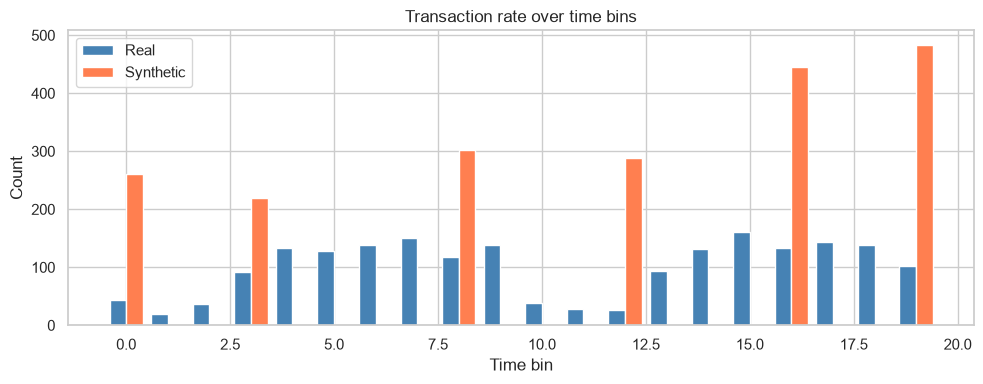

In [12]:
n_bins = 20
real_bins = np.histogram(seed_df["Time"], bins=n_bins)[0]
synth_bins = np.histogram(synthetic_df["Time"], bins=n_bins)[0]
x = np.arange(n_bins)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - 0.2, real_bins, width=0.4, label="Real", color="steelblue")
ax.bar(x + 0.2, synth_bins, width=0.4, label="Synthetic", color="coral")
ax.set_title("Transaction rate over time bins")
ax.set_xlabel("Time bin")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Bootstrap uncertainty

In [13]:
bootstrap_metrics = []

for b in range(BOOTSTRAP_N):
    boot_seed = stratified_bootstrap(pool_df, n=SAMPLE_SIZE, random_state=SEED + b)
    boot_result = fit_sample_smartnoise(
        boot_seed,
        synthesizer_name=SYNTHESIZER,
        epsilon=EPSILON,
        preprocessor_eps=PREPROCESSOR_EPS,
        verbose=False,
    )
    boot_privacy = privacy_budget_dict(boot_result)
    boot_metrics = compute_all_metrics(
        real_train=boot_seed,
        synthetic=boot_result.synthetic,
        real_holdout=holdout_df,
        privacy_budget=boot_privacy,
        output_dir=str(OUTPUT_DIR / f"bootstrap_{b}"),
        synthesizer_name=SYNTHESIZER,
    )
    boot_metrics["bootstrap_id"] = b
    bootstrap_metrics.append(boot_metrics)
    print(f"Bootstrap {b + 1}/{BOOTSTRAP_N} complete")

/Users/amin/Desktop/synthetic_data_generation/.venv/lib/python3.14/site-packages/snsynth/mwem.py:492: Warning: Flattened dimensionality of synthetic histogram is less than the number of iterations. This is a privacy risk. Consider increasing your split_factor (especially if it is 1), or decreasing the number of iterations. Dim: 2 Split: [30]
  warnings.warn(
/Users/amin/Desktop/synthetic_data_generation/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/amin

Bootstrap 1/30 complete


/Users/amin/Desktop/synthetic_data_generation/.venv/lib/python3.14/site-packages/snsynth/mwem.py:492: Warning: Flattened dimensionality of synthetic histogram is less than the number of iterations. This is a privacy risk. Consider increasing your split_factor (especially if it is 1), or decreasing the number of iterations. Dim: 2 Split: [30]
  warnings.warn(
/Users/amin/Desktop/synthetic_data_generation/.venv/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/amin/Desktop/synthetic_data_generation/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/

Bootstrap 2/30 complete


/Users/amin/Desktop/synthetic_data_generation/.venv/lib/python3.14/site-packages/snsynth/mwem.py:492: Warning: Flattened dimensionality of synthetic histogram is less than the number of iterations. This is a privacy risk. Consider increasing your split_factor (especially if it is 1), or decreasing the number of iterations. Dim: 2 Split: [30]
  warnings.warn(
/Users/amin/Desktop/synthetic_data_generation/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/amin

...

Bootstrap 28/30 complete


/Users/amin/Desktop/synthetic_data_generation/.venv/lib/python3.14/site-packages/snsynth/mwem.py:492: Warning: Flattened dimensionality of synthetic histogram is less than the number of iterations. This is a privacy risk. Consider increasing your split_factor (especially if it is 1), or decreasing the number of iterations. Dim: 2 Split: [30]
  warnings.warn(
/Users/amin/Desktop/synthetic_data_generation/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/amin

Bootstrap 29/30 complete


/Users/amin/Desktop/synthetic_data_generation/.venv/lib/python3.14/site-packages/snsynth/mwem.py:492: Warning: Flattened dimensionality of synthetic histogram is less than the number of iterations. This is a privacy risk. Consider increasing your split_factor (especially if it is 1), or decreasing the number of iterations. Dim: 2 Split: [30]
  warnings.warn(
/Users/amin/Desktop/synthetic_data_generation/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/amin

Bootstrap 30/30 complete


In [14]:
bootstrap_summary = aggregate_bootstrap_metrics(bootstrap_metrics)
bootstrap_summary = bootstrap_summary.sort_values("metric")

bootstrap_path = OUTPUT_DIR / "bootstrap_metrics.csv"
bootstrap_summary.to_csv(bootstrap_path, index=False)
print(f"Saved: {bootstrap_path}")
bootstrap_summary

Saved: /Users/amin/Desktop/synthetic_data_generation/outputs/bootstrap_metrics.csv


,metric,mean,std,ci_low,ci_high,n
24,azure_all_passed,1.000000,0.000000,1.000000,1.000000,30
26,azure_csv_export_ok,1.000000,0.000000,1.000000,1.000000,30
29,azure_dp_sql_smoke_test_ok,1.000000,0.000000,1.000000,1.000000,30
28,azure_metadata_yaml_ok,1.000000,0.000000,1.000000,1.000000,30
27,azure_parquet_export_ok,1.000000,0.000000,1.000000,1.000000,30
25,azure_python_version_ok,1.000000,0.000000,1.000000,1.000000,30
30,bootstrap_id,14.500000,8.803408,0.725000,28.275000,30
6,fidelity_class_prevalence_error,0.032033,0.064969,0.001362,0.226400,30
5,fidelity_corr_l2_diff,2.381308,0.200881,2.144572,2.794679,20
1,fidelity_ks_max,0.882383,0.082264,0.699487,0.985712,30


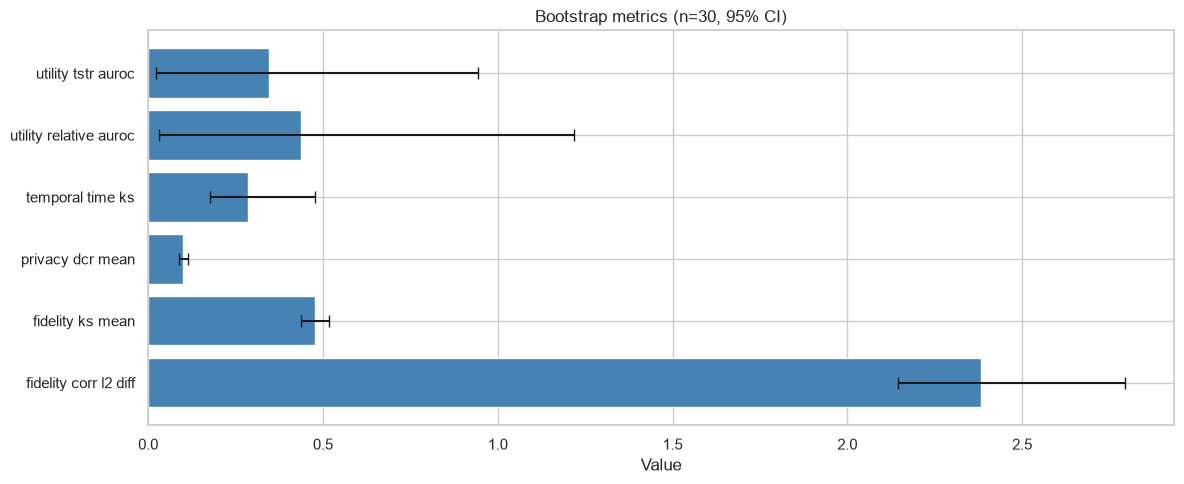

In [15]:
key_metrics = [
    "fidelity_ks_mean",
    "fidelity_corr_l2_diff",
    "temporal_time_ks",
    "privacy_dcr_mean",
    "privacy_mia_auc",
    "utility_tstr_auroc",
    "utility_relative_auroc",
]

plot_df = bootstrap_summary[bootstrap_summary["metric"].isin(key_metrics)].copy()
plot_df["label"] = plot_df["metric"].str.replace("_", " ")

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(
    plot_df["label"],
    plot_df["mean"],
    xerr=[plot_df["mean"] - plot_df["ci_low"], plot_df["ci_high"] - plot_df["mean"]],
    color="steelblue",
    capsize=4,
)
ax.set_title(f"Bootstrap metrics (n={BOOTSTRAP_N}, 95% CI)")
ax.set_xlabel("Value")
plt.tight_layout()
plt.show()

## 7. Conclusions

- **Statistical fidelity:** Compare `fidelity_ks_mean` and `fidelity_corr_l2_diff` — lower is better for distribution and correlation match.
- **Temporal:** `temporal_time_ks` and `temporal_bin_rate_error` capture whether transaction timing patterns are preserved (SmartNoise treats rows as i.i.d., so temporal fidelity may be limited).
- **Privacy:** `privacy_epsilon_spent` gives the provable DP guarantee; empirical checks (`privacy_dcr_mean`, `privacy_mia_auc`) complement it — lower MIA AUC is better.
- **Azure compatibility:** Artifacts exported to `outputs/` (CSV, Parquet, metadata YAML) with a smartnoise-sql smoke test.
- **Utility:** `utility_relative_auroc` near 1.0 means synthetic data is as useful as real data for fraud detection (TSTR vs TRTR).

Tune `EPSILON` (higher = more utility, less privacy) and try `dpctgan` for better continuous fidelity on larger bootstrap samples.